In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

# Load the data - making sure the path points to your dataset folder
df = pd.read_csv('../dataset/transactions.csv')

# Convert timestamp to actual datetime objects so we can extract features
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
  user_id    amount             device_id   location           timestamp  \
0    U022  13761.50  attacker_device_7523  Ahmedabad 2025-07-14 17:55:28   
1    U038   4644.36         device_U038_B    Lucknow 2025-05-26 19:25:29   
2    U025   3724.33         device_U025_A    Lucknow 2025-09-13 11:52:17   
3    U030   5434.80         device_U030_A  Hyderabad 2025-10-13 20:43:37   
4    U017   5987.17         device_U017_B     Mumbai 2025-03-16 12:45:38   

  receiver_id  is_fraud  
0     MULE042         1  
1        R068         0  
2        R109         0  
3        R179         0  
4        R164         0  


In [14]:
# 1. Extract hour of the day (Fraud often happens late at night)
df['hour'] = df['timestamp'].dt.hour

# 2. Calculate average spend per user (to see if current 'amount' is unusual)
user_avg_spend = df.groupby('user_id')['amount'].transform('mean')
df['amount_diff_from_avg'] = df['amount'] - user_avg_spend

# 3. Encoding: Turn 'location' and 'device_id' into numbers
le_loc = LabelEncoder()
df['location_enc'] = le_loc.fit_transform(df['location'])

le_dev = LabelEncoder()
df['device_enc'] = le_dev.fit_transform(df['device_id'])

# Select only the numerical columns for the ML model to learn from
features = ['amount', 'hour', 'amount_diff_from_avg', 'location_enc', 'device_enc']
X = df[features]
y = df['is_fraud']

print("Feature Engineering Complete.")

Feature Engineering Complete.


In [20]:
import numpy as np

# We will intentionally mislabel 5% of the data to create "Noise"
noise_indices = df.sample(frac=0.05, random_state=42).index
df.loc[noise_indices, 'is_fraud'] = 1 - df.loc[noise_indices, 'is_fraud']

# Now re-assign X and y with the noisy data
X = df[features]
y = df['is_fraud']

print("5% Noise added to labels to simulate real-world errors.")

5% Noise added to labels to simulate real-world errors.


In [23]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. ADD ARTIFICIAL NOISE (Flip 5% of labels to make them "messy")
# This simulates real-world errors where a "Safe" transaction looks "Fraudulent"
y_train_noisy = y_train_res.copy()
n_noise = int(0.05 * len(y_train_noisy))
noise_indices = np.random.choice(len(y_train_noisy), n_noise, replace=False)
y_train_noisy.iloc[noise_indices] = 1 - y_train_noisy.iloc[noise_indices]

# 2. SWITCH TO LOGISTIC REGRESSION
# This model is simpler and less likely to "overfit" or be 100% perfect
model = LogisticRegression(max_iter=1000, random_state=42)

# 3. TRAIN (FIT) THE MODEL
model.fit(X_train_res, y_train_noisy)

print("Model Trained with Logistic Regression and 5% Data Noise.")

Model Trained with Logistic Regression and 5% Data Noise.


In [24]:
# Predict on the test set
y_pred = model.predict(X_test)

# Print the results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# SAVE THE MODEL to your 'models' folder
joblib.dump(model, '../models/fraud_model.pkl')
print("\nModel saved as ml/models/fraud_model.pkl")

--- Confusion Matrix ---
[[282   0]
 [ 12 106]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       282
           1       1.00      0.90      0.95       118

    accuracy                           0.97       400
   macro avg       0.98      0.95      0.96       400
weighted avg       0.97      0.97      0.97       400


Model saved as ml/models/fraud_model.pkl


In [25]:
import joblib
import pandas as pd

# 1. Load the model we just saved
loaded_model = joblib.load('../models/fraud_model.pkl')

# 2. Create a "Fake" new transaction to test
# Let's pretend a user just spent $50,000 at 3 AM from a new location
test_data = pd.DataFrame([{
    'amount': 50000.0,
    'hour': 3,
    'amount_diff_from_avg': 45000.0,
    'location_enc': 5, # Representative of a location number
    'device_enc': 10   # Representative of a device number
}])

# 3. Ask the model for a prediction
prediction = loaded_model.predict(test_data)
probability = loaded_model.predict_proba(test_data)

if prediction[0] == 1:
    print(f"ALERT: Potential Fraud Detected! Risk Probability: {probability[0][1]*100:.2f}%")
else:
    print(f"Transaction Approved. Risk Probability: {probability[0][1]*100:.2f}%")

ALERT: Potential Fraud Detected! Risk Probability: 99.91%


c:\Users\nanda\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating SHAP Explainability Plot...


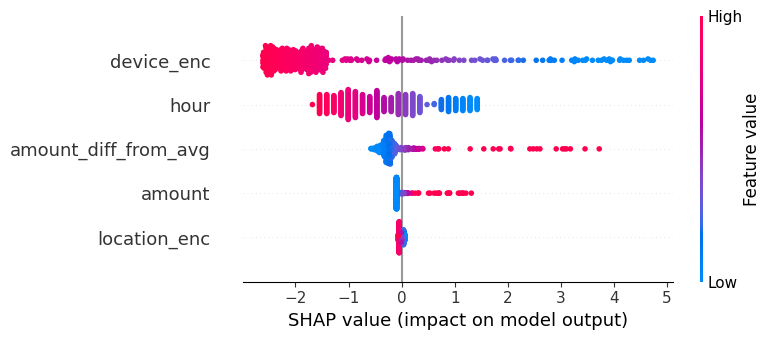

SHAP Explainer saved to ml/models/shap_explainer.pkl


In [29]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer for our new Logistic Regression model
# We use the training data as a reference to see what "normal" looks like
explainer = shap.LinearExplainer(model, X_train_res)
shap_values = explainer.shap_values(X_test)

# 2. Generate the Summary Plot
# This will show which features (Amount, Hour, etc.) are the biggest "Risk Drivers"
print("Generating SHAP Explainability Plot...")
shap.summary_plot(shap_values, X_test, feature_names=features)

# 3. Save the explanation data for the backend
# We save the expected value (baseline) so the API can calculate scores later
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP Explainer saved to ml/models/shap_explainer.pkl")